<a href="https://colab.research.google.com/github/samyladutra/algoritmos-ml/blob/develop/Desafio_modulo1_Bootcamp_engenheiro_machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Desafio prático módulo 1 - Bootcamp Engenheiro de Machine Learning

In [3]:
#importando as bibliotecas
import pandas as pd  #bibioteca responsável para o tratamento e limpeza dos dados
from sklearn.neighbors import KNeighborsClassifier # Importa o KNeighborsClassifier

Primeiras 5 linhas do DataFrame:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Informações sobre as colunas e tipos de dados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


None


Features escalonadas com sucesso usando MinMaxScaler.
Modelo KNeighborsClassifier treinado com sucesso!
Primeiras 10 previsões: [5 5 7 5 7 6 6 5 6 6]
Primeiros 10 valores reais (teste): [5 6 6 6 6 6 6 5 5 5]
Acurácia do modelo: 0.56

Relatório de Classificação:

              precision    recall  f1-score   support

           3       1.00      0.50      0.67         2
           4       0.33      0.05      0.08        21
           5       0.61      0.71      0.65       207
           6       0.54      0.52      0.53       195
           7       0.38      0.35      0.36        52
           8       0.00      0.00      0.00         3

    accuracy                           0.56       480
   macro avg       0.48      0.35      0.38       480
weighted avg       0.54      0.56      0.54       480

Matriz de Confusão:



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Previsto 3,Previsto 4,Previsto 5,Previsto 6,Previsto 7,Previsto 8
Real 3,1,0,0,1,0,0
Real 4,0,1,14,5,1,0
Real 5,0,0,147,55,5,0
Real 6,0,1,72,101,21,0
Real 7,0,1,9,24,18,0
Real 8,0,0,0,0,3,0


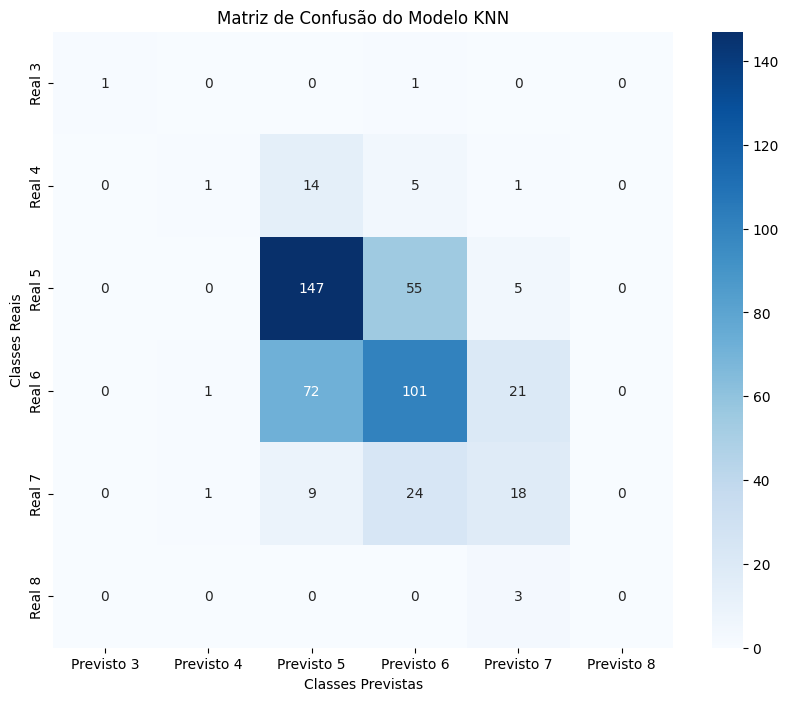

In [14]:
#carregando os dados para o pandas
df_consultas=pd.read_csv('winequality-red.csv', sep=';')

# Visualizando as primeiras linhas do DataFrame para entender as colunas
print("Primeiras 5 linhas do DataFrame:")
display(df_consultas.head())

print("Informações sobre as colunas e tipos de dados:")
display(df_consultas.info())

# Separando features (X) e target (y)
X = df_consultas.drop('quality', axis=1) # Todas as colunas, exceto 'quality'
y = df_consultas['quality'] # A coluna 'quality'

# Importando a função para dividir os dados
from sklearn.model_selection import train_test_split

# Dividindo os dados em conjuntos de treino e teste (70% treino, 30% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# Escalonando as features usando MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures escalonadas com sucesso usando MinMaxScaler.")

# Utilizando o algoritmo KNN para classificação com 5 vizinhos próximos
clf_KNN = KNeighborsClassifier(n_neighbors=5)

# Treinando o modelo com os dados de treino escalonados
clf_KNN.fit(X_train_scaled, y_train)

print("Modelo KNeighborsClassifier treinado com sucesso!")

# Fazendo previsões no conjunto de teste escalonado
y_pred = clf_KNN.predict(X_test_scaled)

print("Primeiras 10 previsões:", y_pred[:10])
print("Primeiros 10 valores reais (teste):", y_test[:10].values)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Calculando a acurácia
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia do modelo: {accuracy:.2f}\n")

# Relatório de classificação (precisão, recall, f1-score para cada classe)
print("Relatório de Classificação:\n")
print(classification_report(y_test, y_pred))

# Matriz de Confusão
print("Matriz de Confusão:\n")
display(pd.DataFrame(confusion_matrix(y_test, y_pred),
                   index=[f'Real {c}' for c in sorted(y.unique())],
                   columns=[f'Previsto {c}' for c in sorted(y.unique())]))

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Recalculando a matriz de confusão (garantir que temos a mais recente)
cm = confusion_matrix(y_test, y_pred)

# Criando o DataFrame para o heatmap com rótulos significativos
cm_df = pd.DataFrame(cm,
                   index=[f'Real {c}' for c in sorted(y.unique())],
                   columns=[f'Previsto {c}' for c in sorted(y.unique())])

# Plotando o heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Matriz de Confusão do Modelo KNN')
plt.xlabel('Classes Previstas')
plt.ylabel('Classes Reais')
plt.show()